# miniGPT

## 代码实现


### 1、导入相关的 package

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from dataclasses import dataclass
import tiktoken  # 分词器

import math

torch.manual_seed(1024)  # 随机种子，通过固定随机数生成器的起点，确保了模型在初始状态（权重和偏置）、训练过程（Dropout 掩码）以及数据处理（Shuffle 顺序）上的一致性，从而实现实验结果的可复现。

### 2、定义GPT的参数

In [30]:
@dataclass  # dataclasses 模块提供的一个装饰器，用于简化类的定义，尤其是那些主要用于存储数据的类。它可以自动生成一些常用的方法，使代码更简洁。
class GPTConfig:
    block_size: int = 512  # 文本的最大长度，即max_seq
    batch_size: int = 12
    n_layer: int = 6
    n_head: int = 12
    n_embd: int = 768
    hidden_dim: int = n_embd
    drop_out: float = 0.1
    head_size: int = n_embd // n_head
    vocab_size: int = 50257  #  GPT2 官方使用的字典大小

### 3、定义GPT的模型结构

In [31]:
# 1、single head attention
class SingleHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.key = nn.Linear(config.hidden_dim, config.head_size)
        self.value = nn.Linear(config.hidden_dim, config.head_size)
        self.query = nn.Linear(config.hidden_dim, config.head_size)
        # 使用register_buffer做mask，不用计算梯度，速度更快
        self.head_size = config.head_size
        self.register_buffer(
            "attention_mask",
            # tril是创建一个下三角矩阵
            torch.tril(
                torch.ones(config.block_size, config.block_size)
            )
        )
        self.dropout = nn.Dropout(config.drop_out)

    def forward(self, x):
        batch_size, seq_len, hidden_dim = x.size()
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        # 最后两个维度进行转置，其实就是最后两个维度数据交换
        weight = q @ k.transpose(-2, -1) / math.sqrt(hidden_dim)
        weight = weight.masked_fill(
            self.attention_mask[:seq_len, :seq_len] == 0,  # 切片，因为创建的mask是block_size*block_size的
            float("-inf")
        )
        weight = F.softmax(weight, -1)
        weight = self.dropout(weight)
        out_put = weight @ v
        return out_put


# 2、multi head attention
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        # 生成的头是并列的
        self.heads = nn.ModuleList(
            SingleHeadAttention(config) for _ in range(config.n_head)
        )
        self.proj = nn.Linear(config.hidden_dim, config.hidden_dim)
        self.dropout = nn.Dropout(config.drop_out)

    def forward(self, x):
        out_put = torch.cat(
            [head(x) for head in self.heads],
            dim=-1
        )
        out_put = self.proj(out_put)
        out_put = self.dropout(out_put)
        return out_put


# 3、feed forward（MLP）,先升维，再降维
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim * 8),
            nn.GLU(),
            nn.Linear(config.hidden_dim * 4, config.hidden_dim),
            nn.Dropout(config.drop_out)
        )

    def forward(self, x):
        return self.net(x)


# 4、block
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.att = MultiHeadAttention(config)
        self.ffn = FeedForward(config)
        self.ln1 = nn.LayerNorm(config.hidden_dim)
        self.ln2 = nn.LayerNorm(config.hidden_dim)

    def forward(self, x):
        x = x + self.att(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


# 5、GPT
class GPT(nn.Module):
    def __init__(self, config):
        self.block_size = config.block_size
        super().__init__()
        self.token_embedding_table = nn.Embedding(config.vocab_size, config.n_embd)
        self.position_embedding_table = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.Sequential(
            *[Block(config) for _ in range(config.n_layer)]
        )
        self.ln_final = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        '''
        # Weight Tying（权重绑定）
        # 通过让输入层和输出层共用同一个权重矩阵，既能成倍减少显存占用，又能让模型对单词含义的“理解”与“生成”保持逻辑统一。
        # 在 PyTorch 中，nn.Embedding(V, D) 和 nn.Linear(D, V) 的权重在内部存储的形状都是 (V, D)。
        # 词嵌入本质上是一本供模型翻阅的“字典”（查找表），它只需要存储每个词的固定坐标，因此在结构上只有权重矩阵，没有执行线性变换所需的偏置项。
        # 所以在权重绑定的时候要去掉偏置值
        '''
        self.token_embedding_table.weight = self.lm_head.weight

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            # 初始化为正态分布
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx 输入是 token ids
        # targets 输入是目标的 token ids
        # 所以二者 shape 一致
        batch, seq_len = idx.size()
        token_emb = self.token_embedding_table(idx)  # (batch, seq_len, n_embd)
        pos_emb = self.position_embedding_table(
            # 创建一个从 0 到 seq_len 的序列，保证位置编码和输入的idx在同一个设备
            torch.arange(seq_len, device=idx.device)
        )
        x = token_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_final(x)
        logits = self.lm_head(x)
        if targets is None:
            loss = None
        else:
            batch, seq_len, vocab_size = logits.size()
            logits = logits.view(batch * seq_len, vocab_size)
            targets = targets.view(batch * seq_len)
            '''
            F.cross_entropy 接收模型输出的原始分（Logits），在内部先执行 Softmax 将其归一化为概率分布，再根据真实索引（Targets）提取正确项概率并取负对数，
            从而算出模型预测与真实答案之间的误差。
            '''
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # 如果序列太长，只取最后 block_size 个token
            idx_cond = idx if idx.size(1) <= self.block_size else idx[:, -self.block_size:]
            # 获取预测s
            logits, _ = self(idx_cond)
            # 只关注最后一个时间步的预测
            logits = logits[:, -1, :]  # becomes (B, vocab_size)
            # 应用softmax获取概率
            probs = F.softmax(logits, dim=-1)
            # # 随机采样下一个token
            # idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            
            # 修改后：直接取概率最大的索引
            idx_next = torch.argmax(probs, dim=-1, keepdim=True)
            
            # 附加到序列上
            idx = torch.cat((idx, idx_next), dim=1)  # (B, T+1)
        return idx

### 4、构建输入的 DataSet

In [32]:
# 数据的格式
"""
jsonl文件
{"text":"担任地点省市的区域运营中心的办理作业。承受总部相关KPI查核。\n1、了解新闻职业或媒体相关运营运营岗位，其间，应聘区域运营中心主任有3年以上当地干流媒体作业经验者优先，应聘事务主管有2年以上当地干流媒体作业经验者优先。\n2、交流才能强，抗压才能强，长于处理复杂情况，了解GR作业优先，能独立完结策划计划优先。具有独立开发客户才能。\n北京、天津、河北、山西、黑龙江、吉林、辽宁、上海、江苏、浙江、安徽、江西、福建、山东、河南、湖北、湖南、广东、海南、重庆、四川、贵州、云南、陕西等。"}
"""


class MyDataset(Dataset):
    def __init__(self, path, block_size=512):
        # 获取gpt2的分词器
        self.enc = tiktoken.get_encoding("gpt2")
        self.block_size = block_size

        self.encoded_data = []
        # 特殊符号分割不同的训练文本
        # <|endoftext|>
        '''
        这行代码通过调用 `self.enc.encode()` 方法，将字符串 `<|endoftext|>` 按允许的特殊 token `{"<|endoftext|>"}` 进行编码，
        得到 token ID 列表，并取第一个 ID 作为 `self.eos_token`（文本结束 token）。
        该token编号早就写好了，代码只是取出来，编号为[50256]
        '''
        self.eos_token = self.enc.encode(
            "<|endoftext|>",
            allowed_special={"<|endoftext|>"}
        )[0]
        import json
        self.max_lines = 1000
        raw_data = []
        with open(path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i >= self.max_lines:
                    break
                try:
                    text = json.loads(line.strip())["text"]
                    raw_data.append(text)
                except Exception as e:
                    continue
        full_encoded = []
        for text in raw_data:
            encoded_text = self.enc.encode(text)  # 返回token的id列表
            full_encoded.extend(encoded_text + [self.eos_token])  # 列表相加

        # block_size = 512，所以要将长文本分割为训练样本
        for i in range(0, len(full_encoded), self.block_size):
            chunk = full_encoded[i:i + self.block_size + 1]  # 每一行实际是513个token
            if len(chunk) < self.block_size + 1:
                # # 如果长度不够，用 eos_token 填充
                chunk = chunk + [self.eos_token] * (self.block_size + 1 - len(chunk))
            self.encoded_data.append(chunk)

    def __len__(self):
        return len(self.encoded_data)

    def __getitem__(self, idx):
        chunk = self.encoded_data[idx]
        # 相当于主动造成了一个位移，左闭右开
        x = torch.tensor(chunk[:-1], dtype=torch.long)  # 输入序列，去掉最后一个token
        y = torch.tensor(chunk[1:], dtype=torch.long)  # 预测目标，去掉第一个token
        return x, y

    def encode(self, text):
        """将文本编码为token IDs"""
        return self.enc.encode(text)

    def decode(self, ids):
        """将token IDs解码为文本"""
        return self.enc.decode(ids)

In [33]:
# train data
train_dataset = MyDataset(
    './datasets/mobvoi_seq_monkey_general_open_corpus.jsonl/mobvoi_seq_monkey_general_open_corpus.jsonl')

# split traindataset to train and val
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [0.9, 0.1])

train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=12, shuffle=False)

for x, y in train_loader:
    print(x.shape, y.shape)
    break

torch.Size([12, 512]) torch.Size([12, 512])


### 5、运行相关的函数

In [34]:
model = GPT(GPTConfig())
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
model.to(device)
# 打印模型参数量
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params / 1e6}M")
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
'''
创建一个使用余弦退火（Cosine Annealing）策略来逐渐降低学习率的学习率调度器，使学习率在 `1000` 个 step 内按余弦曲线从初始值逐步减小。
'''
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000)

Using device: cuda
Total number of parameters: 95.693568M


Training Finished


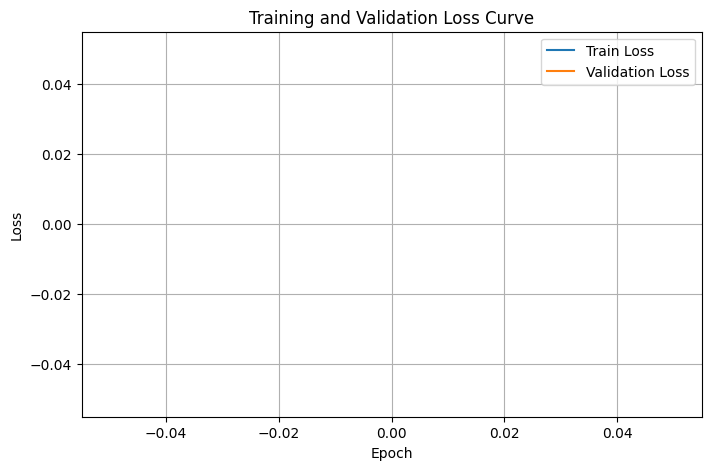

In [35]:
'''
# 完整的训练流程
for epoch in range(num_epochs):
    for data, label in dataloader:
        # 前向传播
        output = model(data)
        # 计算损失
        loss = criterion(output, label)
        # 梯度清零
        optimizer.zero_grad()
        # 反向传播
        loss.backward()
        # 更新参数
        optimizer.step()
'''


# 训练循环
def train(model, optimizer, scheduler, train_loader, val_loader, device):
    model.train()
    total_loss = 0
    for batch_idx, (x, y) in enumerate(train_loader):
        # 将数据迁移到设备上
        # x = x.to(device) 是把变量 x 从指向“内存里的旧数据”改为指向“显存里的新副本”，这样 GPU 才能抓到它进行计算。
        x, y = x.to(device), y.to(device)
        # 前向传播
        logits, loss = model(x, targets=y)
        # 反向传播
        optimizer.zero_grad()  # 将模型参数的梯度清零，避免与上一次计算的梯度累积
        loss.backward()  # 反向传播：根据当前的 loss 计算每个参数的梯度
        optimizer.step()  # 根据计算得到的梯度更新模型参数（执行一次优化器更新）
        # 调整学习率
        scheduler.step()
        total_loss += loss.item()  # 做统计用
        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch},Batch: {batch_idx}, Loss: {loss.item():.4f}')
    return total_loss


def eval(model, val_loader, device):
    # 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits, loss = model(x, targets=y)
            val_loss += loss.item()
    return val_loss


# for epoch in range(200):
#     train_loss = train(model, optimizer, scheduler, train_loader, val_loader, device)
#     val_loss = eval(model, val_loader, device)
#     print(
#         f'Epoch: {epoch}, Train Loss: {train_loss / len(train_loader):.4f}, Val Loss: {val_loss / len(val_loader):.4f}')
# 
#     # 保存模型
#     avg_val_loss = val_loss / len(val_loader)
#     checkpoint = {
#         'epoch': epoch,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'scheduler_state_dict': scheduler.state_dict(),
#         'val_loss': avg_val_loss,
#     }
#     # 保存每个epoch的模型
#     torch.save(checkpoint, f'checkpoints/model_epoch_{epoch}.pt')

import os
import torch
import matplotlib.pyplot as plt

# 创建保存目录
os.makedirs("checkpoints", exist_ok=True)

num_epochs = 200
best_val_loss = float('inf')

# 用于记录loss
train_losses = []
val_losses = []

for epoch in range(200):

    # ========== 训练 ==========
    train_loss = train(model, optimizer, scheduler, train_loader, val_loader, device)

    # ========== 验证 ==========
    val_loss = eval(model, val_loader, device)

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    # 记录loss
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    # checkpoint内容
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "val_loss": avg_val_loss,
    }

    # ========== 保存最优模型 ==========
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(checkpoint, "checkpoints/best_model.pt")

        print(f"✅ Best model saved (epoch {epoch+1}, val_loss={avg_val_loss:.4f})")

print("Training Finished")

# ===============================
# 画 Loss 曲线
# ===============================

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")

plt.legend()
plt.grid(True)

plt.savefig("checkpoints/loss_curve.png")
plt.show()


In [36]:
import torch
import tiktoken


def generate_response(prompt, model_path, config, max_new_tokens=100):
    # 1. 硬件检测
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 2. 实例化模型结构
    model = GPT(config)

    # 3. 加载训练好的权重
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()  # 必须切换到推理模式（关闭 Dropout 等）

    # 4. 初始化分词器
    enc = tiktoken.get_encoding("gpt2")

    # 5. 将你的问题转换成 Token IDs
    # 加上 <|endoftext|> 是为了符合训练时的分布
    start_ids = enc.encode(prompt)
    x = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)  # 增加 batch 维度

    # 6. 调用模型生成
    print(f"--- 正在生成回答 ---")
    with torch.no_grad():  # 推理时不需要计算梯度，节省内存
        y = model.generate(x, max_new_tokens=max_new_tokens)

    # 7. 解码并打印结果
    result_text = enc.decode(y[0].tolist())
    return result_text



# --- 调用示例 ---
# 假设你想用第 1 个 epoch 保存的模型
my_config = GPTConfig()  # 确保这里的参数和训练时一模一样
model_file = 'checkpoints/best_model.pt'

question = "电容触摸屏生产后只需修正一次或一次即可"  # 建议用你训练集里类似的开头测试
answer = generate_response(question, model_file, my_config, max_new_tokens=400)
print(answer)

--- 正在生成回答 ---
电容触摸屏生产后只需修正一次或一次即可以提供的，那么，那么，那么，那么，那么，那么，那么，那么，那么，那么，那么，那么，那么，那么，那么，那么，鲜么，鲜么，银屑银银银银，银么银银银银银屑，银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银银�
